# test_vw_full_hom_particular

In this notebook, I check the newest `VWDecomp` solution set and visualize:

- how the fitted coefficient `C` changes from model to model,
- how surface values of `V` and `W` behave across models,
- and how full/homogeneous/particular/matched radial profiles compare for representative stars.

I keep the plotting style close to my other test notebooks and I add short comments so each step is easy to follow later.

In [1]:
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Plot style: I keep this simple and consistent with the test notebooks.
import matplotlib as mpl
# mpl.rcParams["font.family"] = "CMU Serif"
mpl.rcParams["figure.dpi"] = 200
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["legend.frameon"] = False

## 1) Load the newest `VWDecomp` data

First I read the run config (`h`, `eps`) so paths are resolved from the same setup used by the solver.

Then I load:

- `RGrid` (background radius grid),
- `VWfull`, `VWhom`, `VWpart`, `VWmatched`,
- and the metadata file that stores the fitted `C` and surface-condition diagnostics per model.

In [2]:
def _patch_numpy_pickle_modules():
    """
    Compatibility shim for pickles saved with numpy._core.* module names.
    """
    try:
        import numpy.core as np_core
        import numpy.core.numeric as np_core_numeric
        sys.modules.setdefault("numpy._core", np_core)
        sys.modules.setdefault("numpy._core.numeric", np_core_numeric)
    except Exception:
        pass

_patch_numpy_pickle_modules()

BASE = Path.cwd().resolve().parent  # .../high_bg_order_sol
if BASE.name != "high_bg_order_sol":
    BASE = Path.cwd().resolve()

CFG_PATH = BASE / "config" / "h_eps_config.pkl"
with open(CFG_PATH, "rb") as f:
    cfg = pickle.load(f)

h_tok = str(cfg["h"])
eps_tok = str(cfg["eps"])

target_dir = BASE / "numpy_grid" / f"h{h_tok}_eps{eps_tok}"
decomp_dir = target_dir / "VWDecomp"

r_path = target_dir / f"RGrid_h{h_tok}_eps{eps_tok}.pkl"
if not r_path.exists():
    alt = target_dir / f"Rgrid_h{h_tok}_eps{eps_tok}.pkl"
    if alt.exists():
        r_path = alt

full_path = decomp_dir / f"VWfull_grid_h{h_tok}_eps{eps_tok}.pkl"
hom_path = decomp_dir / f"VWhom_grid_h{h_tok}_eps{eps_tok}.pkl"
part_path = decomp_dir / f"VWpart_grid_h{h_tok}_eps{eps_tok}.pkl"
matched_path = decomp_dir / f"VWmatched_grid_h{h_tok}_eps{eps_tok}.pkl"
meta_path = decomp_dir / f"VWfull_hom_particular_meta_h{h_tok}_eps{eps_tok}.pkl"

with open(r_path, "rb") as f:
    Rgrid = pickle.load(f)
with open(full_path, "rb") as f:
    VW_full = pickle.load(f)
with open(hom_path, "rb") as f:
    VW_hom = pickle.load(f)
with open(part_path, "rb") as f:
    VW_part = pickle.load(f)
with open(matched_path, "rb") as f:
    VW_matched = pickle.load(f)
with open(meta_path, "rb") as f:
    payload = pickle.load(f)

records = payload["records"]
meta = payload["meta"]
n_models = len(records)

print("r_path      :", r_path)
print("decomp_dir  :", decomp_dir)
print("meta_path   :", meta_path)
print("timestamp   :", meta.get("timestamp"))
print("n_models    :", n_models)
print("surface logic:", meta.get("surface_index_logic"))

r_path      : /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/RGrid_h1e-4_eps1e-3.pkl
decomp_dir  : /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/VWDecomp
meta_path   : /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/VWDecomp/VWfull_hom_particular_meta_h1e-4_eps1e-3.pkl
timestamp   : 2026-03-18T03:28:48
n_models    : 25
surface logic: surface_index=max(min(len(r),len(p),len(m),len(rho),len(lambda),len(drho),len(h00),len(h00p))-4,2)


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_17804/1593086468.py:44: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  VW_full = pickle.load(f)
/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_17804/1593086468.py:46: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usa

## 2) Build helper functions and model-level arrays

Here I prepare lightweight helpers so I can pull the same model cleanly from each grid.

Important detail: each model is already trimmed using the solver's `surface_index` convention, and I use the same index from `records` to align radius and solution arrays.

In [3]:
def grid_shape(n):
    if n <= 5:
        return 1, n
    if n <= 10:
        return 2, 5
    if n <= 15:
        return 3, 5
    if n <= 20:
        return 4, 5
    if n <= 25:
        return 5, 5
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))
    return rows, cols


def unpack_vw(vw_model):
    arr = np.asarray(vw_model, dtype=float)
    return arr[:, 0], arr[:, 1]


def get_model_bundle(i):
    rec = records[i]
    sidx = int(rec["surface_index"])
    r_use = np.asarray(Rgrid[i], dtype=float)[:sidx]

    v_full, w_full = unpack_vw(VW_full[i])
    v_hom, w_hom = unpack_vw(VW_hom[i])
    v_part, w_part = unpack_vw(VW_part[i])
    v_mat, w_mat = unpack_vw(VW_matched[i])

    n = min(len(r_use), len(v_full), len(v_hom), len(v_part), len(v_mat))
    r_use = r_use[:n]

    return {
        "rec": rec,
        "r": r_use,
        "full": (v_full[:n], w_full[:n]),
        "hom": (v_hom[:n], w_hom[:n]),
        "part": (v_part[:n], w_part[:n]),
        "matched": (v_mat[:n], w_mat[:n]),
    }


# Arrays for model-wise summaries
model_id = np.arange(n_models)
C_arr = np.array([float(r["C"]) for r in records], dtype=float)
R_arr = np.array([float(r["R_surf"]) for r in records], dtype=float)
M_arr = np.array([float(r["M_surf"]) for r in records], dtype=float)
compactness = M_arr / R_arr

Vsurf_full = np.array([float(r["V_surf_full"]) for r in records], dtype=float)
Vsurf_hom = np.array([float(r["V_surf_hom"]) for r in records], dtype=float)
Vsurf_part = np.array([float(r["V_surf_part"]) for r in records], dtype=float)
Vsurf_mat = np.array([float(get_model_bundle(i)["matched"][0][-1]) for i in range(n_models)], dtype=float)

Wsurf_full = np.array([float(r["W_surf_full"]) for r in records], dtype=float)
Wsurf_hom = np.array([float(r["W_surf_hom"]) for r in records], dtype=float)
Wsurf_part = np.array([float(r["W_surf_part"]) for r in records], dtype=float)
Wsurf_mat = np.array([float(get_model_bundle(i)["matched"][1][-1]) for i in range(n_models)], dtype=float)

print("C range:", np.nanmin(C_arr), "to", np.nanmax(C_arr))
print("compactness range:", np.nanmin(compactness), "to", np.nanmax(compactness))

C range: -638.5822203302014 to -4.841794702762832
compactness range: 0.043833241267912756 to 0.24788421418021525


## 3) Plot `C` across models

This is the first sanity check I want: I plot fitted `C` by model index and also against compactness (`M/R`).

How `C` is obtained in the computation (at the solver surface index, i.e. shrink-4 convention):

1. I evaluate the surface-condition functional

$$\mathcal{S}(V, W, W'; R_s)=0,$$

where in this project `\mathcal{S}` is the expression from `surface_condition_v0.txt`.

2. I build the matched fields with one free coefficient:

$$V_{\mathrm{m}} = V_{\mathrm{part}} + C\,V_{\mathrm{hom}}, \qquad W_{\mathrm{m}} = W_{\mathrm{part}} + C\,W_{\mathrm{hom}}.$$

And for derivatives at the same surface point:

$$W'_{\mathrm{m}} = W'_{\mathrm{part}} + C\,W'_{\mathrm{hom}}, \qquad W'_{\mathrm{part}} = W'_{\mathrm{full}} - W'_{\mathrm{hom}}.$$

3. Because `\mathcal{S}` contains terms independent of `(V, W, W')` (through `H` and `H'`), I explicitly compute:

$$\mathcal{S}_{0} = \mathcal{S}(0,0,0), \quad \mathcal{S}_{\mathrm{part}} = \mathcal{S}(V_{\mathrm{part}}, W_{\mathrm{part}}, W'_{\mathrm{part}}), \quad \mathcal{S}_{\mathrm{hom}} = \mathcal{S}(V_{\mathrm{hom}}, W_{\mathrm{hom}}, W'_{\mathrm{hom}}).$$

Then the homogeneous linear contribution is

$$\mathcal{L}_{\mathrm{hom}} = \mathcal{S}_{\mathrm{hom}} - \mathcal{S}_{0},$$

and the coefficient I use in the solver is

$$C = -\frac{\mathcal{S}_{\mathrm{part}}}{\mathcal{L}_{\mathrm{hom}}} = -\frac{\mathcal{S}_{\mathrm{part}}}{\mathcal{S}_{\mathrm{hom}}-\mathcal{S}_{0}}.$$

So the plots below are tracking exactly this fitted `C` for each stellar model.

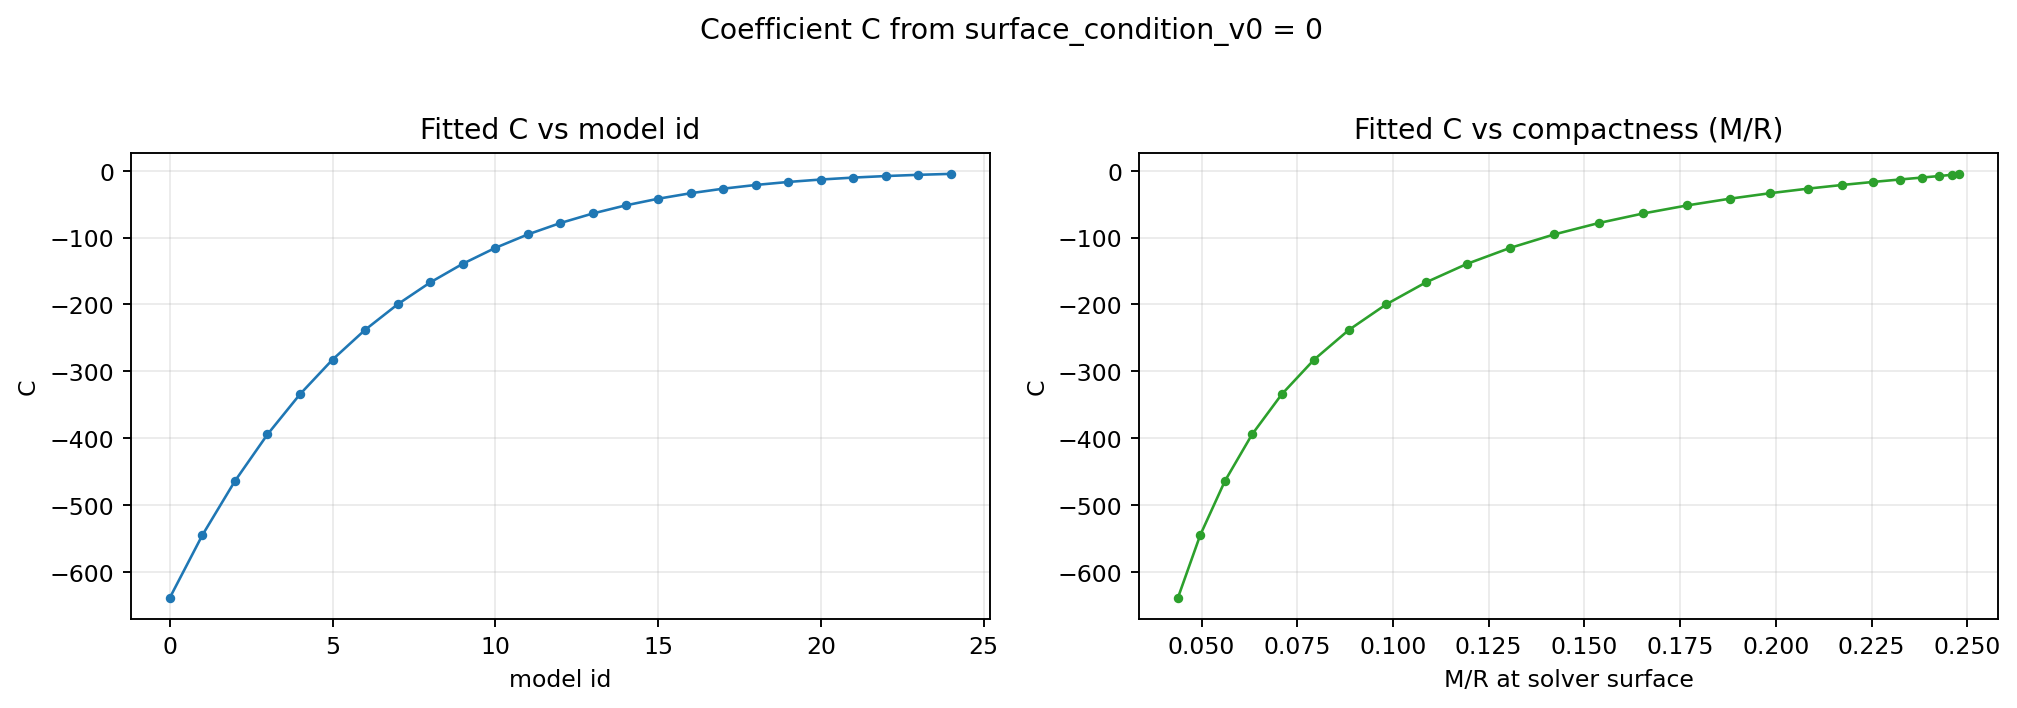

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi=170)

axs[0].plot(model_id, C_arr, marker="o", ms=3.0, lw=1.1, color="tab:blue")
axs[0].set_title("Fitted C vs model id")
axs[0].set_xlabel("model id")
axs[0].set_ylabel("C")

axs[1].plot(compactness, C_arr, marker="o", ms=3.0, lw=1.1, color="tab:green")
axs[1].set_title("Fitted C vs compactness (M/R)")
axs[1].set_xlabel("M/R at solver surface")
axs[1].set_ylabel("C")

plt.suptitle("Coefficient C from surface_condition_v0 = 0", y=1.03)
plt.tight_layout()
plt.show()

## 4) Plot surface `V` and `W` across models

For plotting, I only keep the **matched** branch visible now.

The `full`, `homogeneous`, and `particular` arrays are still computed and kept in the notebook data,
but I comment out their plot lines here so the figure is cleaner.

I keep linear and absolute-log views for the matched solution.

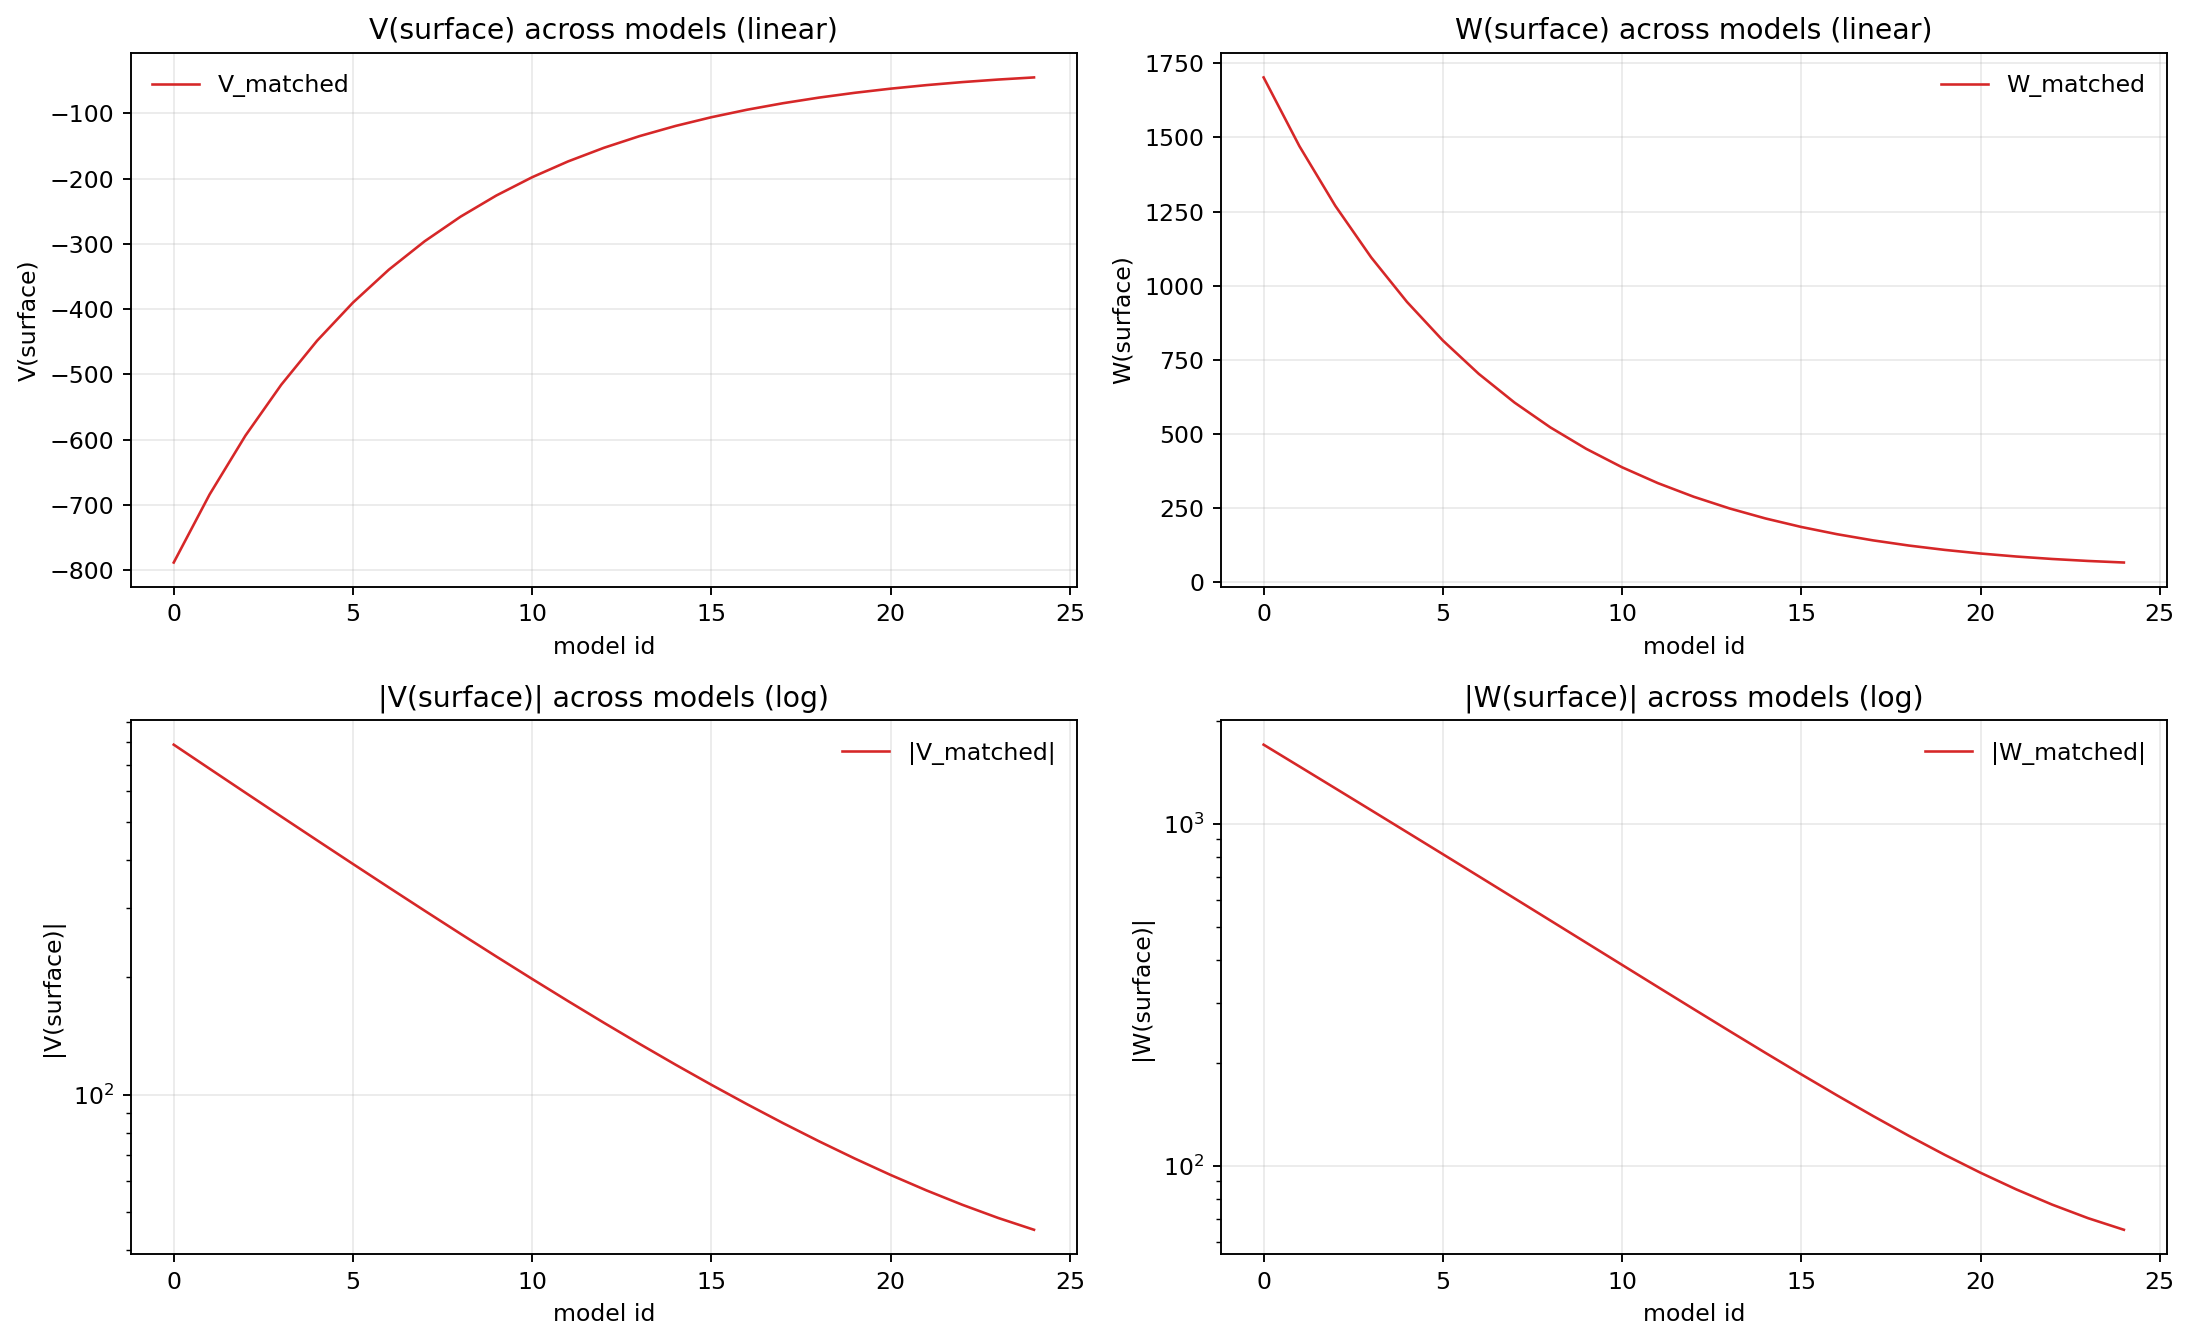

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(13, 8), dpi=170)

# --- V at surface (linear) ---
# axs[0, 0].plot(model_id, Vsurf_full, "-", lw=1.0, label="V_full", color="tab:blue")
# axs[0, 0].plot(model_id, Vsurf_hom, "-", lw=1.0, label="V_hom", color="tab:orange")
# axs[0, 0].plot(model_id, Vsurf_part, "-", lw=1.0, label="V_part", color="tab:green")
axs[0, 0].plot(model_id, Vsurf_mat, "-", lw=1.1, label="V_matched", color="tab:red")
axs[0, 0].set_title("V(surface) across models (linear)")
axs[0, 0].set_xlabel("model id")
axs[0, 0].set_ylabel("V(surface)")
axs[0, 0].legend(ncol=1)

# --- W at surface (linear) ---
# axs[0, 1].plot(model_id, Wsurf_full, "-", lw=1.0, label="W_full", color="tab:blue")
# axs[0, 1].plot(model_id, Wsurf_hom, "-", lw=1.0, label="W_hom", color="tab:orange")
# axs[0, 1].plot(model_id, Wsurf_part, "-", lw=1.0, label="W_part", color="tab:green")
axs[0, 1].plot(model_id, Wsurf_mat, "-", lw=1.1, label="W_matched", color="tab:red")
axs[0, 1].set_title("W(surface) across models (linear)")
axs[0, 1].set_xlabel("model id")
axs[0, 1].set_ylabel("W(surface)")
axs[0, 1].legend(ncol=1)

# --- |V| at surface (log) ---
# axs[1, 0].plot(model_id, np.abs(Vsurf_full), "-", lw=1.0, label="|V_full|", color="tab:blue")
# axs[1, 0].plot(model_id, np.abs(Vsurf_hom), "-", lw=1.0, label="|V_hom|", color="tab:orange")
# axs[1, 0].plot(model_id, np.abs(Vsurf_part), "-", lw=1.0, label="|V_part|", color="tab:green")
axs[1, 0].plot(model_id, np.abs(Vsurf_mat), "-", lw=1.1, label="|V_matched|", color="tab:red")
axs[1, 0].set_yscale("log")
axs[1, 0].set_title("|V(surface)| across models (log)")
axs[1, 0].set_xlabel("model id")
axs[1, 0].set_ylabel("|V(surface)|")
axs[1, 0].legend(ncol=1)

# --- |W| at surface (log) ---
# axs[1, 1].plot(model_id, np.abs(Wsurf_full), "-", lw=1.0, label="|W_full|", color="tab:blue")
# axs[1, 1].plot(model_id, np.abs(Wsurf_hom), "-", lw=1.0, label="|W_hom|", color="tab:orange")
# axs[1, 1].plot(model_id, np.abs(Wsurf_part), "-", lw=1.0, label="|W_part|", color="tab:green")
axs[1, 1].plot(model_id, np.abs(Wsurf_mat), "-", lw=1.1, label="|W_matched|", color="tab:red")
axs[1, 1].set_yscale("log")
axs[1, 1].set_title("|W(surface)| across models (log)")
axs[1, 1].set_xlabel("model id")
axs[1, 1].set_ylabel("|W(surface)|")
axs[1, 1].legend(ncol=1)

plt.tight_layout()
plt.show()

## 5) Matched profiles for all 25 stars (5x5)

To make this easier to read, I now plot only the **matched** solution for every model on a fixed 5x5 grid.

I use two panels:

- linear scale: `V_matched(r)` and `W_matched(r)`
- log scale: `|V_matched(r)|` and `|W_matched(r)|`

So I can see both sign/shape behavior and magnitude behavior across the whole stellar sequence.

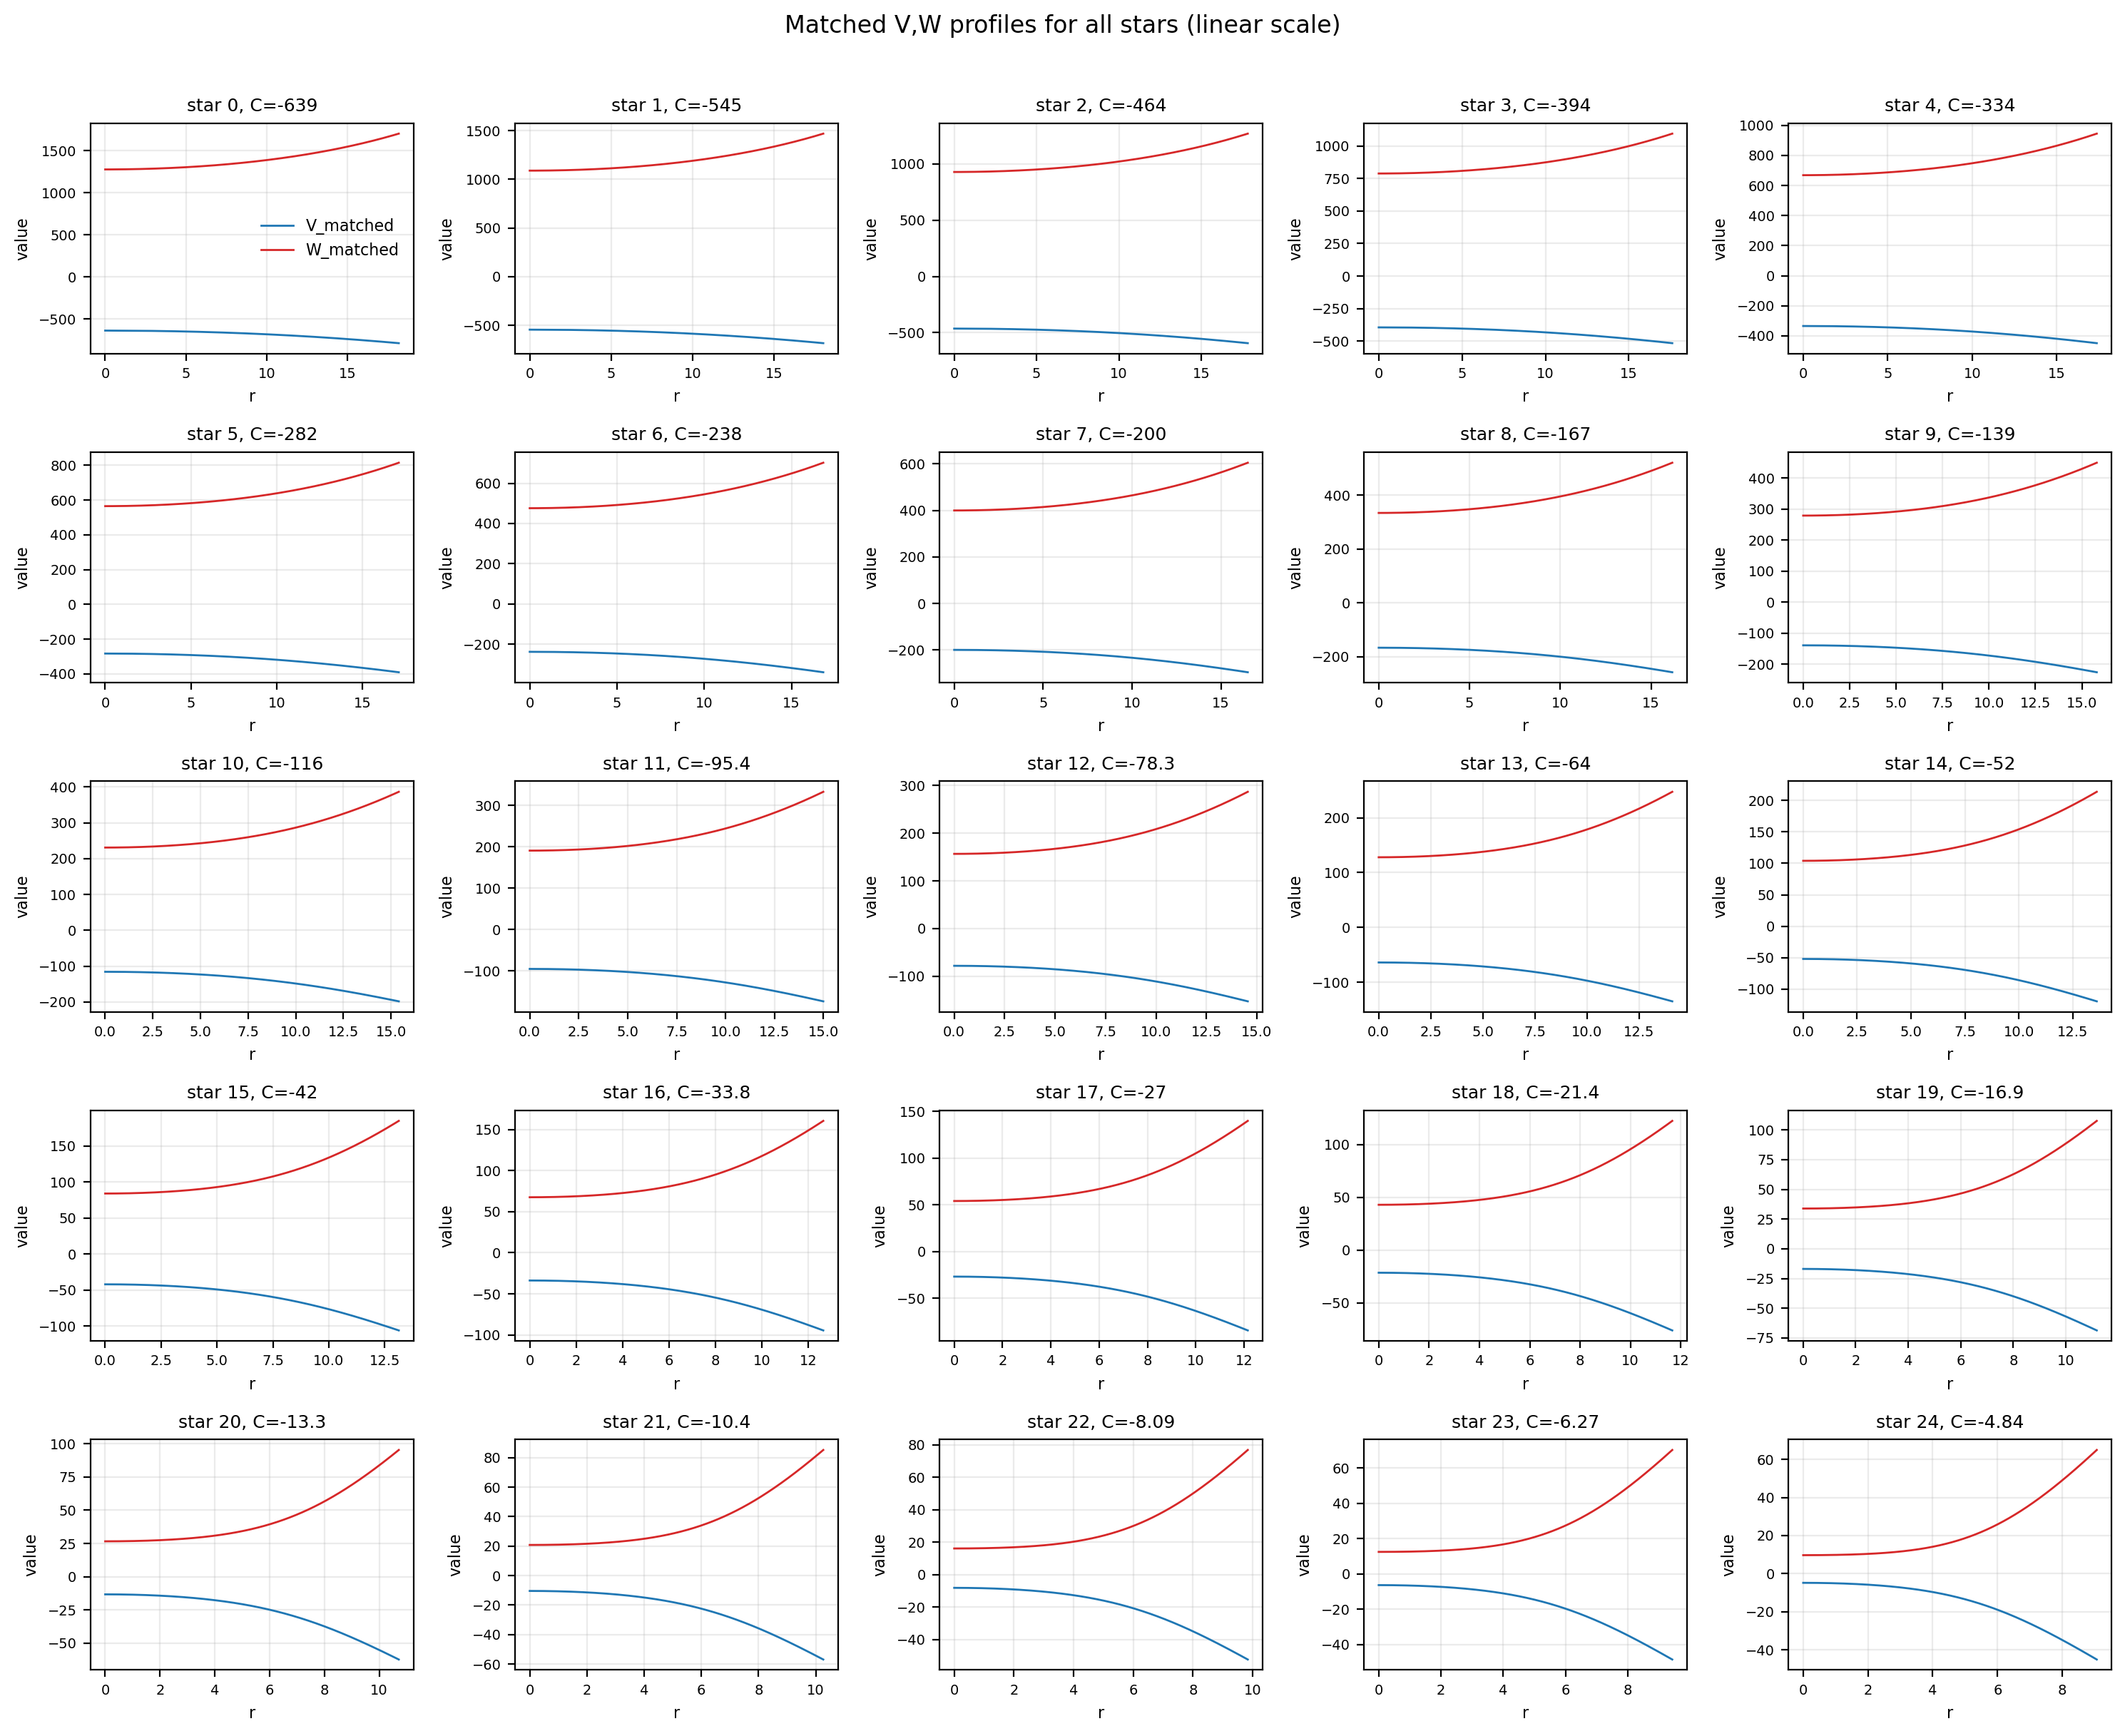

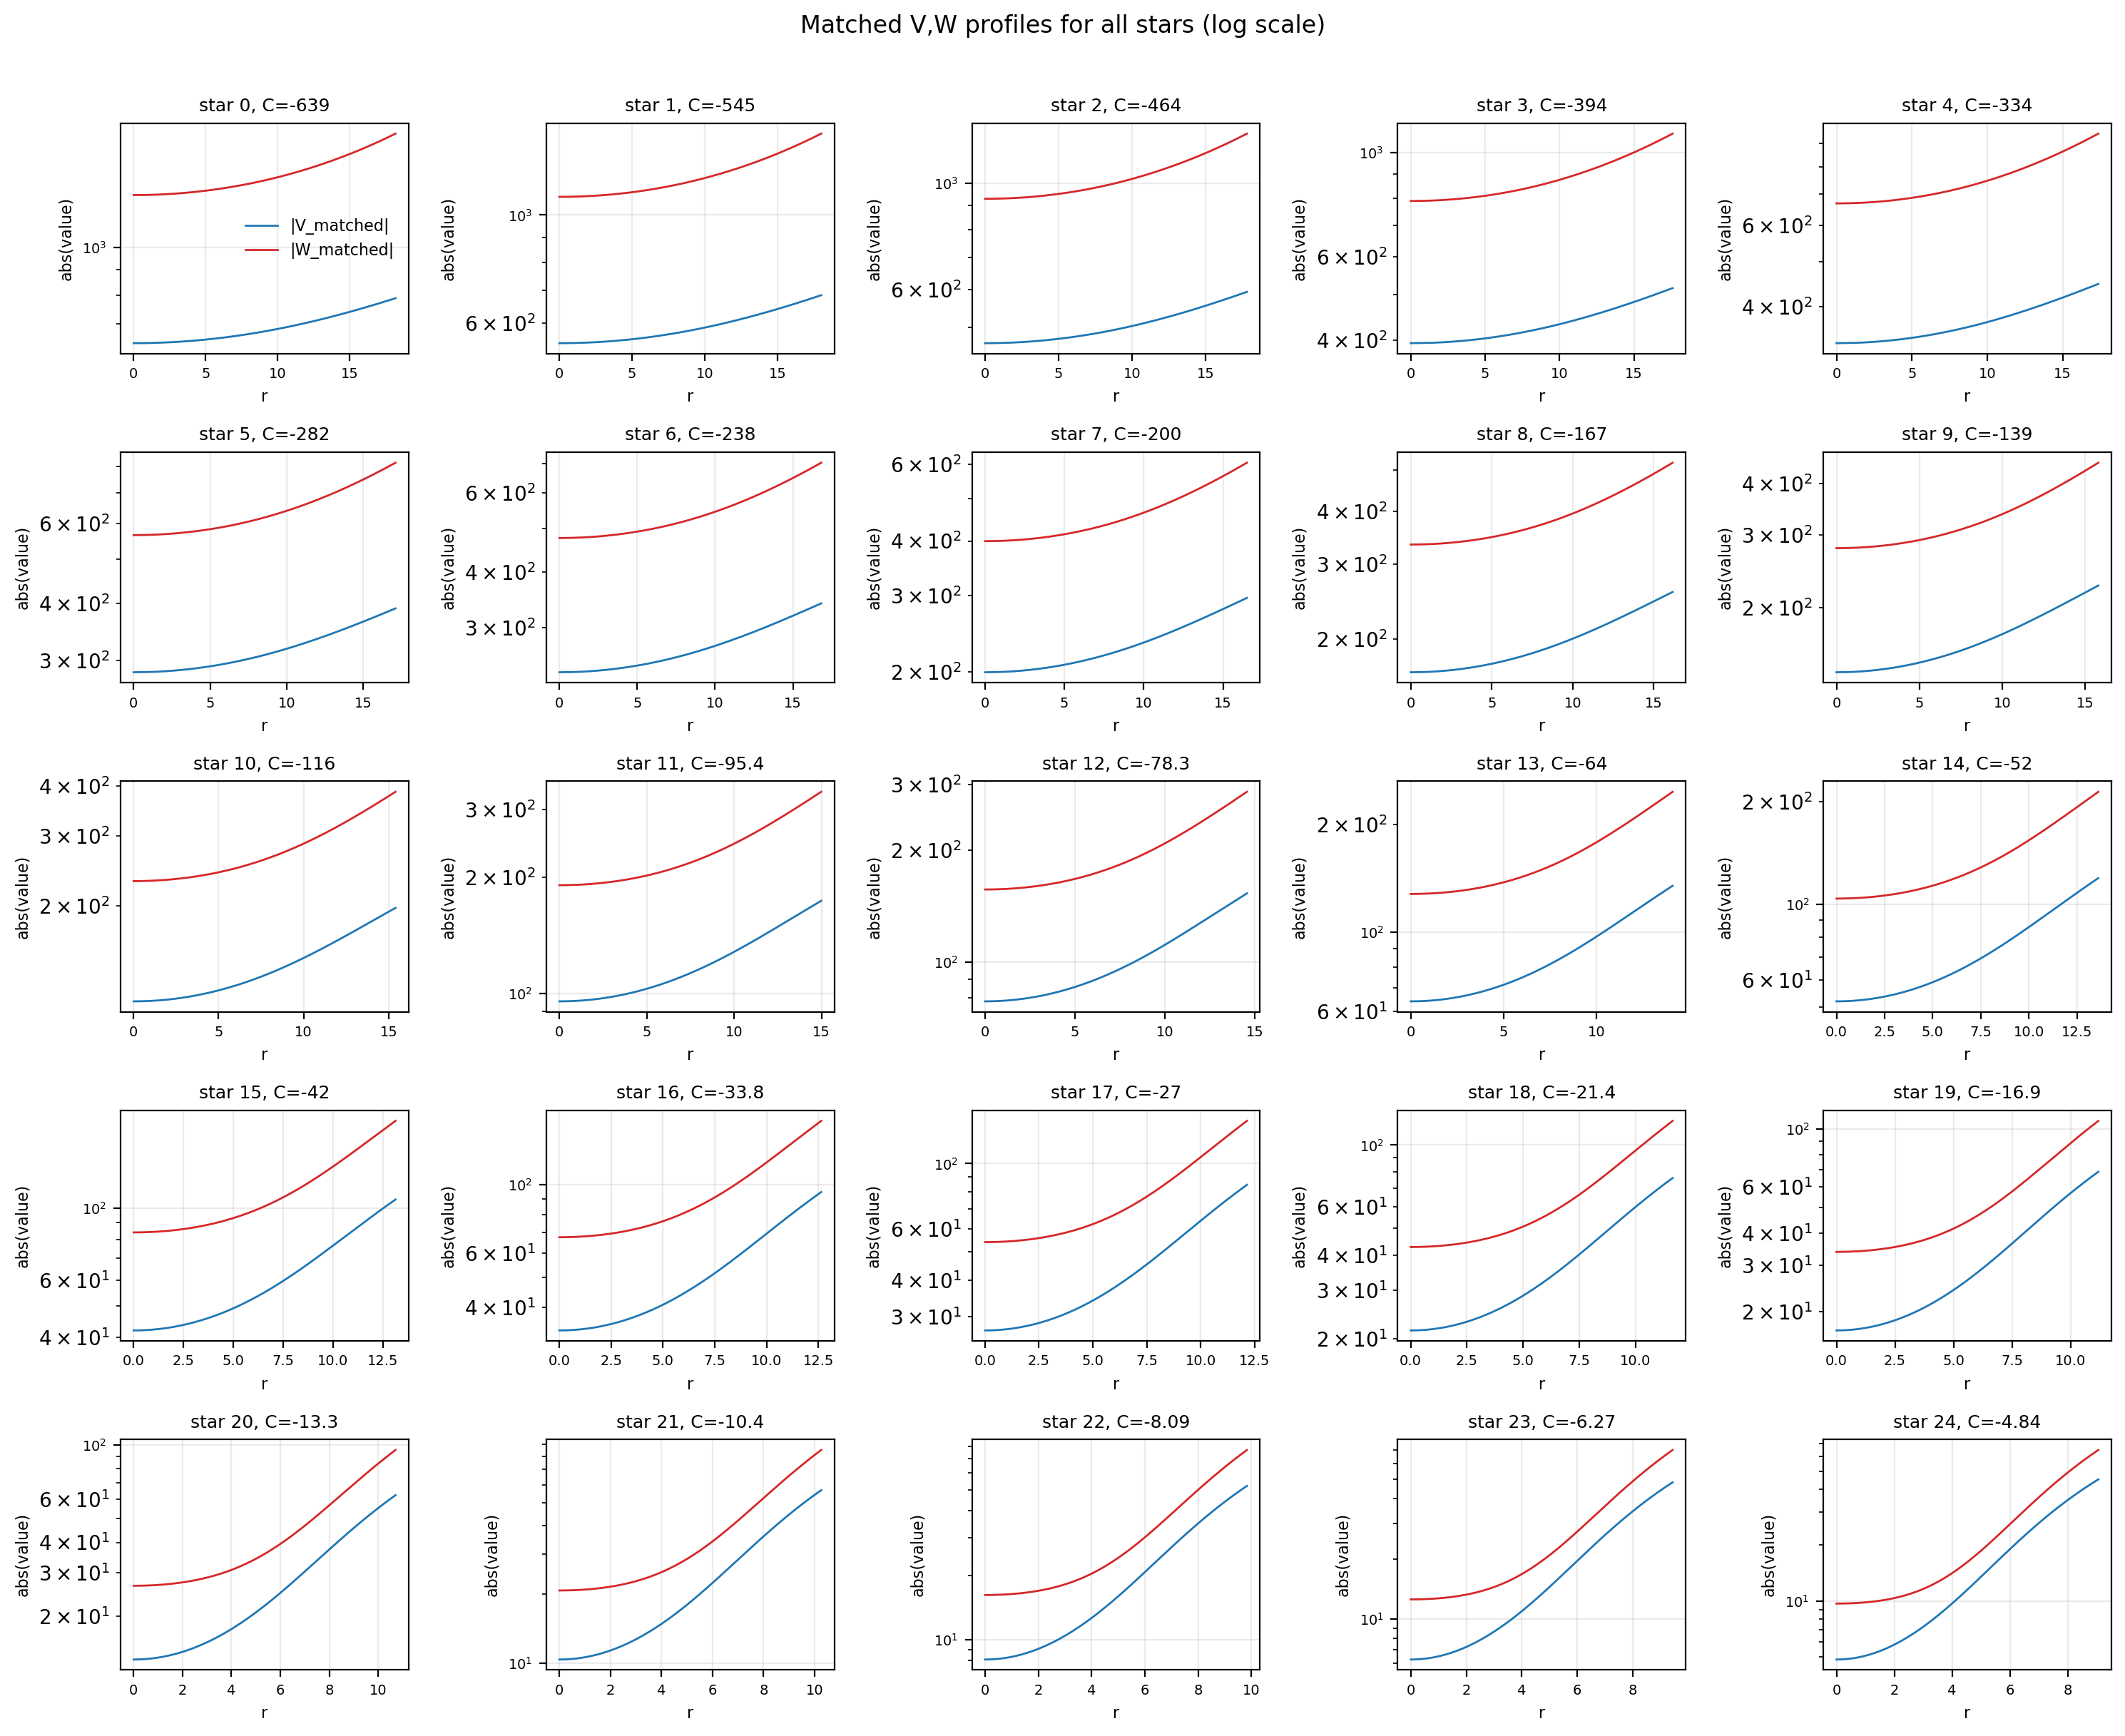

In [6]:
n_plot = min(25, n_models)
rows, cols = 5, 5

# --- (A) Linear scale: matched V and W for all stars ---
fig, axs = plt.subplots(rows, cols, figsize=(3 * cols, 2.4 * rows), dpi=200)
axs = np.atleast_1d(axs).reshape(rows, cols)

for i in range(rows * cols):
    ax = axs[i // cols, i % cols]
    if i >= n_plot:
        ax.axis("off")
        continue

    d = get_model_bundle(i)
    r = d["r"]
    v_mat, w_mat = d["matched"]

    ax.plot(r, v_mat, lw=1.0, color="tab:blue", label="V_matched")
    ax.plot(r, w_mat, lw=1.0, color="tab:red", label="W_matched")
    ax.set_title(f"star {i}, C={records[i]['C']:.3g}", fontsize=9)
    ax.set_xlabel("r", fontsize=8)
    ax.set_ylabel("value", fontsize=8)
    ax.tick_params(labelsize=7)

    if i == 0:
        ax.legend(fontsize=8, loc="best")

plt.suptitle("Matched V,W profiles for all stars (linear scale)", y=1.01)
plt.tight_layout()
plt.show()

# --- (B) Log scale: absolute matched V and W for all stars ---
fig, axs = plt.subplots(rows, cols, figsize=(3 * cols, 2.4 * rows), dpi=200)
axs = np.atleast_1d(axs).reshape(rows, cols)

eps = 1e-300  # avoid log(0)

for i in range(rows * cols):
    ax = axs[i // cols, i % cols]
    if i >= n_plot:
        ax.axis("off")
        continue

    d = get_model_bundle(i)
    r = d["r"]
    v_mat, w_mat = d["matched"]

    ax.plot(r, np.maximum(np.abs(v_mat), eps), lw=1.0, color="tab:blue", label="|V_matched|")
    ax.plot(r, np.maximum(np.abs(w_mat), eps), lw=1.0, color="tab:red", label="|W_matched|")
    ax.set_yscale("log")
    ax.set_title(f"star {i}, C={records[i]['C']:.3g}", fontsize=9)
    ax.set_xlabel("r", fontsize=8)
    ax.set_ylabel("abs(value)", fontsize=8)
    ax.tick_params(labelsize=7)

    if i == 0:
        ax.legend(fontsize=8, loc="best")

plt.suptitle("Matched V,W profiles for all stars (log scale)", y=1.01)
plt.tight_layout()
plt.show()

## 6) Surface-condition check after matching

Final sanity check: I compare the surface-condition values before and after matching.

I expect the matched branch to sit near zero (up to numerical tolerance), while full/part/hom values can be much larger.

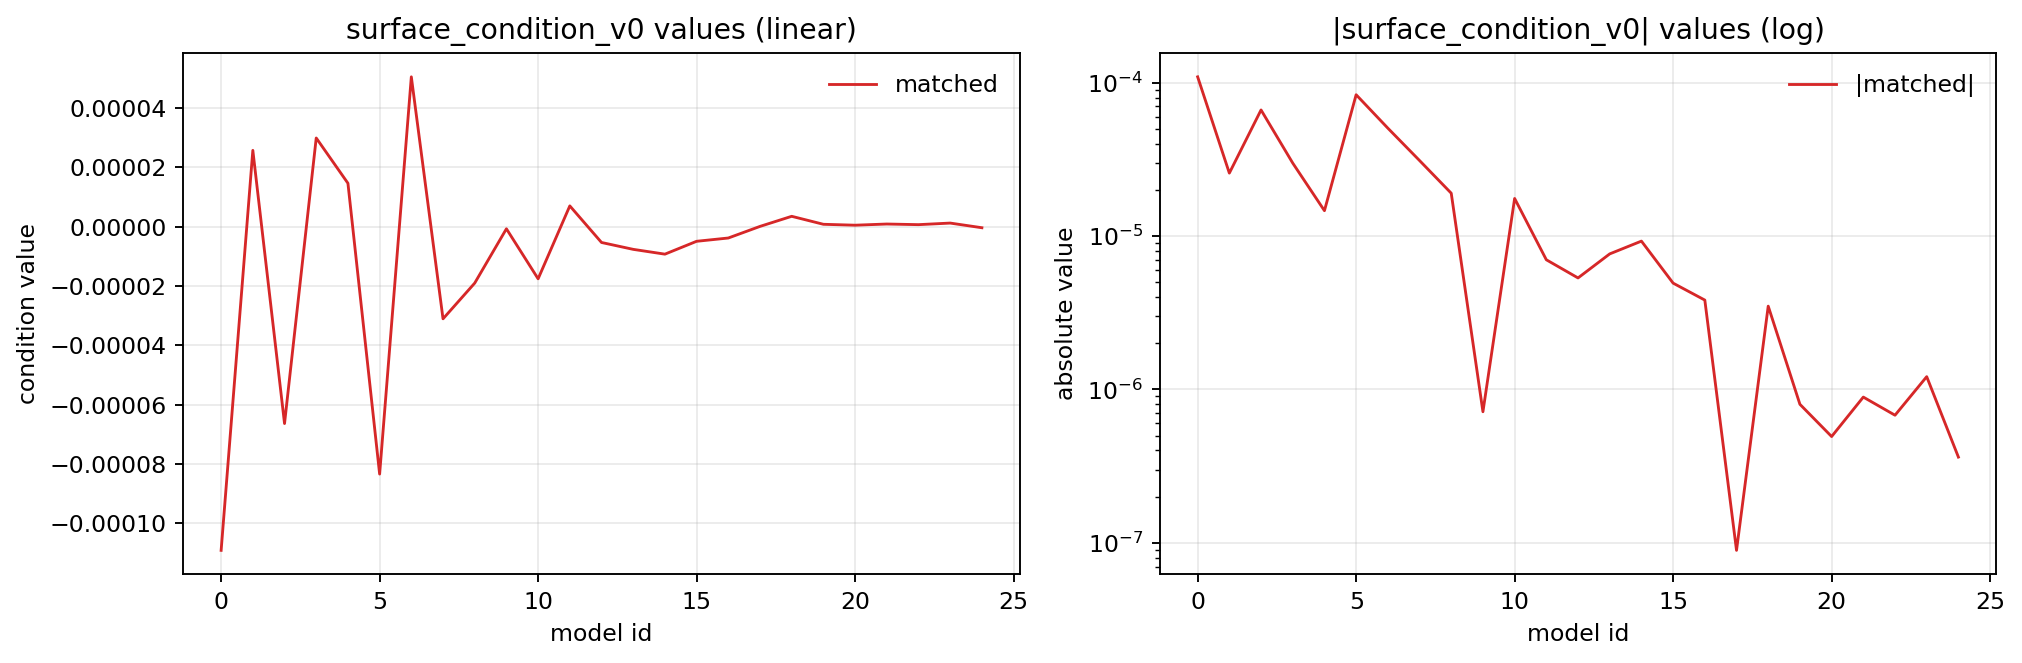

max |surface_condition_matched| = 0.00010913707842519216


In [7]:
sc_full = np.array([float(r["surface_condition_full"]) for r in records], dtype=float)
sc_hom = np.array([float(r["surface_condition_hom"]) for r in records], dtype=float)
sc_part = np.array([float(r["surface_condition_part"]) for r in records], dtype=float)
sc_mat = np.array([float(r["surface_condition_matched"]) for r in records], dtype=float)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi=170)

# axs[0].plot(model_id, sc_full, lw=1.0, label="full", color="tab:blue")
# axs[0].plot(model_id, sc_hom, lw=1.0, label="hom", color="tab:orange")
# axs[0].plot(model_id, sc_part, lw=1.0, label="part", color="tab:green")
axs[0].plot(model_id, sc_mat, lw=1.2, label="matched", color="tab:red")
axs[0].set_title("surface_condition_v0 values (linear)")
axs[0].set_xlabel("model id")
axs[0].set_ylabel("condition value")
axs[0].legend()

# axs[1].plot(model_id, np.abs(sc_full), lw=1.0, label="|full|", color="tab:blue")
# axs[1].plot(model_id, np.abs(sc_hom), lw=1.0, label="|hom|", color="tab:orange")
# axs[1].plot(model_id, np.abs(sc_part), lw=1.0, label="|part|", color="tab:green")
axs[1].plot(model_id, np.abs(sc_mat), lw=1.2, label="|matched|", color="tab:red")
axs[1].set_yscale("log")
axs[1].set_title("|surface_condition_v0| values (log)")
axs[1].set_xlabel("model id")
axs[1].set_ylabel("absolute value")
axs[1].legend()

plt.tight_layout()
plt.show()

print("max |surface_condition_matched| =", np.nanmax(np.abs(sc_mat)))